<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Heat%20Transfer/E_20_238_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heat Transfer

# ME 421 - Mechanical Systems Laboratory

## Problem Statement
A factory involved with the manufacturing of dairy products is required to store milk received from the collecting centers in a cool room until delivered to the factory the next day.

Containers made of aluminum are received at around **1400 hrs**. The average temperature of collected milk is in the range of $35^\circ\text{C}$ to $40^\circ\text{C}$. It is required to cool the bulk to $15^\circ\text{C}$ within **two hours** and maintain that temperature until the delivery time at **1400 hrs** the next day.

### 1.1 Parameters & Data
* **Number of containers ($n$):** 40
* **Total mass of milk ($m_m$):** $40 \times 5 = 200 \text{ kg}$
* **Total mass of containers ($m_c$):** $40 \times 2 = 80 \text{ kg}$
* **Specific heat of milk ($C_{p,m}$):** $4000 \text{ J/kg K}$
* **Specific heat of Aluminum ($C_{p,c}$):** $921.1 \text{ J/kg K}$
* **Initial Temperature ($T_{i}$):** $37.5^\circ\text{C}$
* **Final Temperature ($T_{f}$):** $15^\circ\text{C}$
* **Temperature Change ($\Delta T$):** $22.5 \text{ K}$
---

### Task
As the group of engineers for the factory, analyze the suitability of the available unit (**Air Conditioning unit at the Heat Engine Laboratory**) for this purpose.

1.  **Propose a method** to find out the feasibility of the available unit.
2.  **Experiment** with the cooling unit in the Heat Engine Laboratory and obtain the necessary data.
3.  **Determine the developments** required for the unit if the capacity is increased to store $80$ milk containers per day.
4.  **Produce a report** on your findings.

## 1. Cooling Load Calculation

To check whether the cooling unit is suitable, we calculate the total heat energy $Q_{total}$ that must be removed to reduce the temperature of milk and its containers within 2 hours.

### 1.1 Energy Equations
The total heat removed is the sum of heat removed from the milk and from the containers:

$$Q_{total} = (m_m \cdot C_{p,m} \cdot \Delta T) + (m_c \cdot C_{p,c} \cdot \Delta T)$$

**Where:**
* $m_m$: mass of milk
* $C_{p,m}$: specific heat capacity of milk
* $m_c$: mass of containers
* $C_{p,c}$: specific heat capacity of container material
* $\Delta T$: temperature difference

---

### Step-by-Step Calculation

**Heat Removed from Milk:**
$$Q_{milk} = 200 \times 4000 \times 22.5$$
$$Q_{milk} = 18,000,000 \, \text{J}$$

**Heat Removed from Containers:**
$$Q_{cont} = 80 \times 921.1 \times 22.5$$
$$Q_{cont} = 1,657,980 \, \text{J}$$

**Total Heat Removal:**
$$Q_{total} = 18,000,000 + 1,657,980$$
$$Q_{total} = 19,657,980 \, \text{J}$$
$$Q_{total} \approx 19.66 \, \text{MJ}$$

---

### 1.2 Required Cooling Power $\dot{Q}_{req}$
The cooling must be completed within $t = 7200 \, \text{s}$ (2 hours).

$$\dot{Q}_{req} = \frac{Q_{total}}{t}$$
$$\dot{Q}_{req} = \frac{19,657,980}{7200}$$
$$\dot{Q}_{req} \approx 2730.28 \, \text{W}$$
$$\dot{Q}_{req} \approx 2.73 \, \text{kW}$$

> **Conclusion:** The Air Conditioning unit must provide a minimum sensible cooling capacity of **2.73 kW** (excluding additional heat gains such as wall conduction and air infiltration) to achieve the required cooling within 2 hours.

---

### 1.3 Maximum Initial Temperature Case ($T_i = 40^\circ\text{C}$)
This is the worst-case condition.

**Total Heat Removal:**
$$Q = 40 \times [(5 \times 4000 + 2 \times 921.1) \times (40 - 15)]$$
$$Q = 21,842,200 \, \text{J}$$
$$Q \approx 21.84 \, \text{MJ}$$

**Required Cooling Power:**
$$\dot{Q}_{max} = \frac{Q}{t}$$
$$\dot{Q}_{max} = \frac{21,842,200}{7200}$$
$$\dot{Q}_{max} \approx 3.03 \, \text{kW}$$

> **Final Conclusion:** For safety, the cooling system should be rated at a minimum of **3.03 kW** to handle the worst-case initial temperature of $40^\circ\text{C}$.

In [2]:
# --- Cooling System Laboratory Parameters ---

units_count = 40                 # Total number of units (n)
mass_container = 2.0             # Mass of aluminum container per unit (kg)
mass_milk = 5.0                  # Mass of milk per unit (kg)

cp_container = 921.1             # Specific heat of aluminum (J/kg·K)
cp_milk = 4000.0                 # Specific heat of milk (J/kg·K)

T_final = 15.0                   # Target storage temperature (°C)
cooling_time_hr = 2              # Cooling duration (hours)

# Convert cooling time into seconds
cooling_time_sec = cooling_time_hr * 3600


def calculate_cooling_capacity(T_initial):
    """
    Calculate required refrigeration capacity in kW.
    Formula used:
    Q = m * Cp * ΔT
    Power = Q / time
    """

    delta_T = T_initial - T_final

    # Energy removed from milk
    Q_milk = units_count * mass_milk * cp_milk * delta_T

    # Energy removed from containers
    Q_container = units_count * mass_container * cp_container * delta_T

    # Total energy removal (Joules)
    Q_total = Q_milk + Q_container

    # Required cooling capacity (kW)
    cooling_power_kw = (Q_total / cooling_time_sec) / 1000

    return cooling_power_kw


# --- Operating Temperature Scenarios ---

T_nominal = 37.5      # Average arrival temperature (°C)
T_worst = 40.0        # Maximum arrival temperature (°C)

capacity_nominal = calculate_cooling_capacity(T_nominal)
capacity_worst = calculate_cooling_capacity(T_worst)

print("----- Refrigeration Capacity Analysis -----")
print(f"Initial Temperature: {T_nominal} °C  | Required Capacity: {capacity_nominal:.3f} kW")
print(f"Initial Temperature: {T_worst} °C    | Required Capacity: {capacity_worst:.3f} kW")


----- Refrigeration Capacity Analysis -----
Initial Temperature: 37.5 °C  | Required Capacity: 2.730 kW
Initial Temperature: 40.0 °C    | Required Capacity: 3.034 kW


## 2. Performance Evaluation Methodology

This section describes the experimental procedure used to determine the actual cooling capacity $\dot{Q}_{act}$ of the HVAC system. The objective is to verify whether the laboratory air-conditioning unit can satisfy the calculated cooling load required for the milk storage application.

### 2.1 Primary Measurement Variables
The performance analysis requires measurement of airflow and thermodynamic properties at the evaporator section.

#### 2.1.1 Internal Duct Dimensions
Measure the Width ($w$) and Height ($h$) of the duct. The cross-sectional flow area is calculated as:
$$A = w \times h$$

#### 2.1.2 Intake Air Velocity
Air velocity ($v$) is measured using a digital anemometer. Measurements are taken at multiple locations across the duct face to account for the velocity profile. The average value is used for calculations:
$$v_{avg} = \frac{\sum v_i}{n}$$

#### 2.1.3 Psychrometric Measurements
Using a digital psychrometer, measure the Dry Bulb Temperature ($T_{db}$) and Wet Bulb Temperature ($T_{wb}$) at two locations:
* **State 1 (Inlet / Upstream):** Warm air entering the evaporator.
* **State 2 (Outlet / Downstream):** Cooled air leaving the evaporator.

Using a psychrometric chart or property calculator, determine:
* Inlet Enthalpy $\rightarrow h_{in} \text{ (kJ/kg)}$
* Outlet Enthalpy $\rightarrow h_{out} \text{ (kJ/kg)}$



---

### 2.2 Governing Analytical Equations
The cooling capacity is determined from the air mass flow rate and the enthalpy differential.

#### 2.2.1 Air Mass Flow Rate
$$\dot{m}_a = \rho \times A \times v$$
**Where:**
* $\rho \approx 1.2 \, \text{kg/m}^3$ (standard air density)
* $A$ = duct cross-sectional area ($\text{m}^2$)
* $v$ = average air velocity ($\text{m/s}$)

#### 2.2.2 Actual Cooling Capacity
$$\dot{Q}_{act} = \dot{m}_a \times (h_{in} - h_{out})$$
**Units Check:**
* $\dot{m}_a \rightarrow \text{kg/s}$
* $h \rightarrow \text{kJ/kg}$
* **Result** $\rightarrow \text{kW}$

This value represents the total heat removed by the evaporator coil from the airstream.

---

### 2.3 Summary of Experimental Observations

| Variable Description | Notation | Units | Observation |
| :--- | :---: | :---: | :--- |
| Effective Duct Area | $A$ | $\text{m}^2$ | |
| Mean Air Velocity | $v$ | $\text{m/s}$ | |
| Specific Enthalpy (Inlet) | $h_{in}$ | $\text{kJ/kg}$ | |
| Specific Enthalpy (Outlet) | $h_{out}$ | $\text{kJ/kg}$ | |
| Air Mass Flow Rate | $\dot{m}_a$ | $\text{kg/s}$ | |
| **Net Cooling Capacity** | $\dot{Q}_{act}$ | **kW** | |

---

### 2.4 Feasibility Assessment
To validate system performance, the experimentally determined cooling capacity is compared against the required design loads.

**Design Criteria:**
* **Minimum Required Load:** $2.73 \, \text{kW}$
* **Critical Worst-Case Load:** $3.03 \, \text{kW}$

#### Evaluation Logic

*  **Pass Condition:** If $\dot{Q}_{act} \ge 3.03 \, \text{kW}$
    *The system is fully capable of handling worst-case operating conditions.*

*  **Marginal Condition:** If $2.73 \le \dot{Q}_{act} < 3.03 \, \text{kW}$
    *The system meets nominal demand but may struggle under peak load.*

*  **Fail Condition:** If $\dot{Q}_{act} < 2.73 \, \text{kW}$
    *The system capacity is insufficient for the required cooling task.*

## 3. Experimental Data and Analysis of Fan Speed Performance

This section presents the experimental data collected at various evaporator fan speed settings. The cold room door was kept open to maintain a relatively stable inlet air condition while varying the airflow rate. The objective was to determine the fan speed that produces the maximum cooling performance.

### 3.1 Nomenclature and Measurement Points
To ensure clarity, the temperature and flow measurement points are defined as follows:

* $T_1$ : Return air dry bulb temperature ($^\circ\text{C}$)
* $T_2$ : Return air wet bulb temperature ($^\circ\text{C}$)
* $T_3$ : Evaporator inlet dry bulb temperature ($^\circ\text{C}$)
* $T_4$ : Evaporator inlet wet bulb temperature ($^\circ\text{C}$)
* $T_5$ : Evaporator exit dry bulb temperature ($^\circ\text{C}$)
* $T_6$ : Evaporator exit wet bulb temperature ($^\circ\text{C}$)
* $V_{in}$ : Air velocity at evaporator inlet ($\text{m/s}$)
* $V_{out}$ : Air velocity at evaporator outlet ($\text{m/s}$)

**Analysis Basis:**
The actual cooling performance is evaluated between:
$$\text{State Inlet: } (T_3, T_4) \quad \rightarrow \quad \text{State Outlet: } (T_5, T_6)$$

---

### 3.2 Recorded Experimental Data

| Fan Speed | $T_1$ | $T_2$ | $T_3$ | $T_4$ | $T_5$ | $T_6$ | $V_{in}$ | $V_{out}$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 29.5 | 25.2 | 29.1 | 21.2 | 26.4 | 19.9 | 0.0 | 0.0 |
| 2 | 29.5 | 25.3 | 29.1 | 21.1 | 26.7 | 20.0 | 0.0 | 0.0 |
| 3 | 29.9 | 25.3 | 29.5 | 21.5 | 24.3 | 19.7 | 0.6 | 0.5 |
| 4 | 30.0 | 24.9 | 29.6 | 21.8 | 20.4 | 16.6 | 2.8 | 2.6 |
| 5 | 29.2 | 23.7 | 29.3 | 21.2 | 20.8 | 16.2 | 5.6 | 5.4 |
| 6 | 29.2 | 23.3 | 29.3 | 21.1 | 21.4 | 18.0 | 8.8 | 8.1 |
| 7 | 29.4 | 23.2 | 29.3 | 21.1 | 21.5 | 18.2 | 9.3 | 8.4 |
| 8 | 29.0 | 23.1 | 29.1 | 21.0 | 21.2 | 17.6 | 9.6 | 8.5 |
| 9 | 28.7 | 22.9 | 28.9 | 20.9 | 21.3 | 17.4 | 9.8 | 8.7 |
| **10** | **29.4** | **23.2** | **29.3** | **21.1** | **19.9** | **16.5** | **9.5** | **9.1** |

---

### 3.3 Reasoning and Performance Analysis

#### 3.3.1 Evaporator Cooling Effect
The total heat removed by the evaporator occurs between $(T_3, T_4) \rightarrow (T_5, T_6)$. The key indicator of cooling performance is the reduction in air enthalpy:
$$\dot{Q} = \dot{m}_a (h_{in} - h_{out})$$

Since wet bulb temperature ($T_{wb}$) directly relates to total air enthalpy, the difference $(T_4 - T_6)$ represents the magnitude of the total cooling effect (sensible + latent heat).

#### 3.3.2 Influence of Mass Flow Rate
Air mass flow rate depends on velocity: $\dot{m}_a = \rho A v$. As fan speed increases, both velocity and mass flow rate increase, generally increasing total cooling capacity.
* **Peak Airflow:** The maximum inlet velocity was observed at **Speed 9** ($V_{in} = 9.8 \, \text{m/s}$).

#### 3.3.3 High-Speed Performance Evaluation
At **Fan Speed 10**, although the velocity ($9.5 \, \text{m/s}$) is slightly lower than Speed 9, we observe:
* **Lowest Exit Dry Bulb:** $T_5 = 19.9^\circ\text{C}$
* **Lowest Exit Wet Bulb:** $T_6 = 16.5^\circ\text{C}$

This indicates a greater enthalpy reduction per unit of air, suggesting improved cooling effectiveness. This is likely due to an optimized balance between airflow volume and contact time with the evaporator coils. Therefore, **Speed 10** is identified as providing the most effective performance.

---

### 3.4 Feasibility Conclusion

To confirm system adequacy, determine enthalpy values from a psychrometric chart:
1. Use $T_4 \rightarrow h_{in}$
2. Use $T_6 \rightarrow h_{out}$
3. Calculate $\dot{Q} = \dot{m}_a (h_{in} - h_{out})$

**Decision Criteria:**
* **Suitable:** $\dot{Q} \ge 3.03 \, \text{kW}$ (Handles worst-case scenario)
* **Marginal:** $2.73 \le \dot{Q} < 3.03 \, \text{kW}$ (Meets nominal load only)
* *Insufficient:** $\dot{Q} < 2.73 \, \text{kW}$ (System failed)

<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3057962059.py:28: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Outlet Dry Bulb Temperature ($^\circ$C)', fontsize=11)


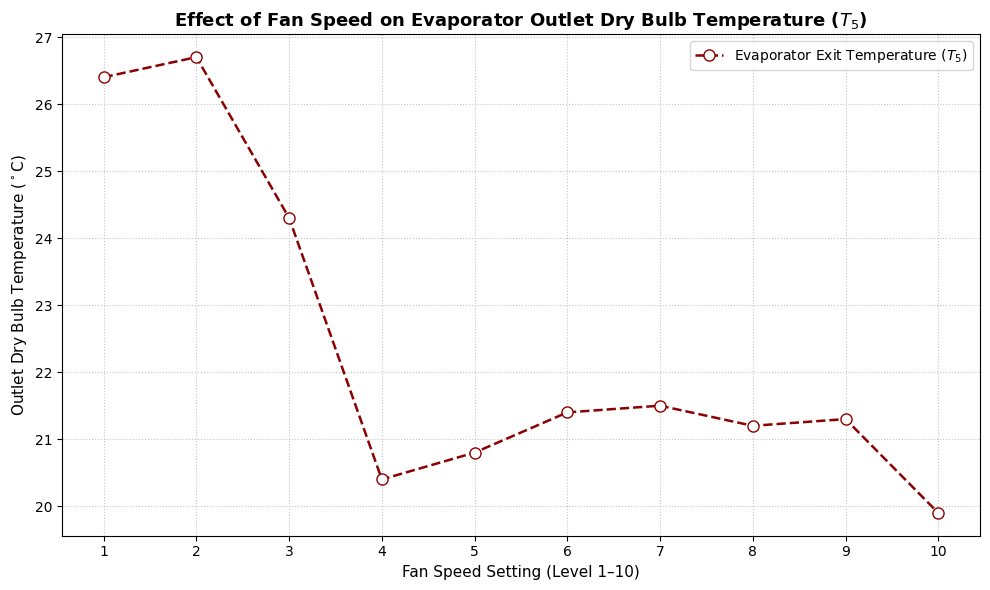

In [5]:
# --- Visualization: Evaporator Exit Temperature vs Fan Speed ---

import matplotlib.pyplot as plt

# Experimental dataset
fan_speed_levels = [1,2,3,4,5,6,7,8,9,10]
T5_exit_db = [26.4, 26.7, 24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9]

# Create figure
plt.figure(figsize=(10,6))

# Plot curve
plt.plot(fan_speed_levels,
         T5_exit_db,
         marker='o',
         linestyle='--',
         linewidth=1.8,
         color='darkred',
         markerfacecolor='white',
         markersize=8)

# Title and labels
plt.title('Effect of Fan Speed on Evaporator Outlet Dry Bulb Temperature ($T_5$)',
          fontsize=13,
          fontweight='bold')

plt.xlabel('Fan Speed Setting (Level 1–10)', fontsize=11)
plt.ylabel('Outlet Dry Bulb Temperature ($^\circ$C)', fontsize=11)

# Force discrete x-axis ticks
plt.xticks(fan_speed_levels)

# Grid formatting
plt.grid(True, linestyle=':', alpha=0.75)

# Legend
plt.legend(['Evaporator Exit Temperature ($T_5$)'],
           loc='upper right',
           frameon=True)

# Layout adjustment
plt.tight_layout()

# Display graph
plt.show()


## 5. Analytical Framework: Thermodynamic Evaluation

This section outlines the mathematical methodology used to determine the actual cooling performance of the HVAC unit using experimental measurements. The cooling capacity is derived from airflow characteristics and psychrometric property calculations.

### 5.1 Air Mass Flow Rate $\dot{m}_a$
The mass flow rate of air entering the evaporator is calculated from the measured inlet velocity and duct geometry:

$$\dot{m}_a = \rho \cdot A \cdot V_{in}$$

**Where:**
* $\rho$: air density ($\rho \approx 1.2 \, \text{kg/m}^3$)
* $A$: duct cross-sectional area ($\text{m}^2$)
* $V_{in}$: average inlet air velocity ($\text{m/s}$)

This determines the total mass of air (kg/s) processed by the evaporator per unit of time.

---

### 5.2 Psychrometric Calculations for Specific Enthalpy $h$
To evaluate the total heat content of moist air (sensible + latent), the dry bulb and wet bulb temperatures are converted into thermodynamic properties using the following sequence.

#### I. Saturation Vapor Pressure at Wet Bulb Temperature
The saturation pressure corresponding to the wet bulb temperature is calculated using the Magnus–Tetens equation:
$$P_{swb} = 0.61078 \cdot \exp \left( \frac{17.27 \cdot T_{wb}}{T_{wb} + 237.3} \right)$$
*Where $T_{wb}$ is the wet bulb temperature ($^\circ\text{C}$) and $P_{swb}$ is in $\text{kPa}$.*

#### II. Actual Vapor Pressure
The partial pressure of water vapor in the air is corrected for the wet-bulb depression:
$$P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db} - T_{wb})$$
*Where $P_{atm} = 101.325 \, \text{kPa}$ (standard atmospheric pressure).*

#### III. Humidity Ratio $\omega$
The moisture content of air (kg water / kg dry air) is determined as:
$$\omega = 0.62194 \cdot \frac{P_v}{P_{atm} - P_v}$$

#### IV. Total Specific Enthalpy $h$
The total enthalpy of moist air is calculated by summing the sensible heat of the air and the total heat of the water vapor:
$$h = (c_{p,a} \cdot T_{db}) + \omega \cdot (h_{fg} + c_{p,v} \cdot T_{db})$$

**Constants:**
* $c_{p,a} = 1.006 \, \text{kJ/kg}\cdot\text{K}$ (dry air specific heat)
* $h_{fg} = 2501 \, \text{kJ/kg}$ (latent heat of vaporization)
* $c_{p,v} = 1.86 \, \text{kJ/kg}\cdot\text{K}$ (water vapor specific heat)

The resulting enthalpy $h$ is expressed in **kJ/kg (dry air basis)**.

---

### 5.3 Net Cooling Capacity $\dot{Q}$
The actual cooling capacity of the evaporator is obtained from the enthalpy difference across the coil:

$$\dot{Q} = \dot{m}_a \cdot (h_{inlet} - h_{outlet})$$

**Where:**
* $h_{inlet}$: Enthalpy derived from return air conditions $(T_3, T_4)$
* $h_{outlet}$: Enthalpy derived from evaporator discharge conditions $(T_5, T_6)$



### Interpretation of Results
* **Higher enthalpy difference:** Indicates greater total heat removal (cooling and dehumidification) per unit mass of air.
* **Higher mass flow rate:** Increases total cooling capacity provided the evaporator coil can maintain a sufficient $\Delta h$.
* **Optimal Efficiency:** Achieved at the fan speed where the product of mass flow and enthalpy drop is maximized.

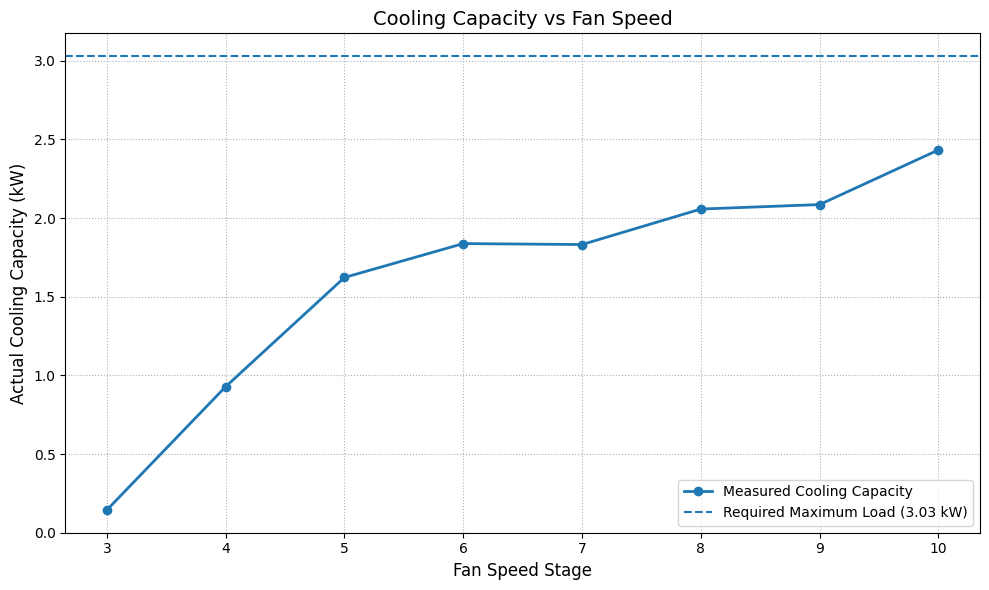


--- HVAC Cooling Performance Summary ---
 fan_stage  velocity     Q_kW
         3       0.6 0.144262
         4       2.8 0.928436
         5       5.6 1.622419
         6       8.8 1.837842
         7       9.3 1.831778
         8       9.6 2.057423
         9       9.8 2.085847
        10       9.5 2.433180


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================= 1. Experimental Dataset =================
# Fan speed performance data (Stages 3–10)

fan_data = {
    "fan_stage": [3, 4, 5, 6, 7, 8, 9, 10],
    "Tdb_in":  [29.9, 30.0, 29.2, 29.2, 29.4, 29.0, 28.7, 29.4],
    "Twb_in":  [25.3, 24.9, 23.7, 23.3, 23.2, 23.1, 22.9, 23.2],
    "Tdb_out": [24.3, 20.4, 20.8, 21.4, 21.5, 21.2, 21.3, 19.9],
    "Twb_out": [19.7, 16.6, 16.2, 18.0, 18.2, 17.6, 17.4, 16.5],
    "velocity": [0.6, 2.8, 5.6, 8.8, 9.3, 9.6, 9.8, 9.5]  # m/s
}

df = pd.DataFrame(fan_data)

# ================= 2. Constants & Duct Geometry =================

P_atm = 101.325        # kPa
rho_air = 1.2          # kg/m³
duct_diam = 0.11       # 110 mm circular duct (m)

# Cross-sectional area (m²)
area = (np.pi * duct_diam**2) / 4


def moist_air_enthalpy(Tdb, Twb):
    """
    Calculate moist air enthalpy (kJ/kg dry air)
    using standard psychrometric relationships.
    """

    # Saturation vapor pressure at wet bulb temperature (kPa)
    Pws = 0.61078 * np.exp((17.27 * Twb) / (Twb + 237.3))

    # Actual vapor pressure (kPa)
    Pv = Pws - 0.000662 * P_atm * (Tdb - Twb)

    # Humidity ratio (kg/kg dry air)
    omega = 0.62194 * Pv / (P_atm - Pv)

    # Enthalpy equation (kJ/kg dry air)
    h = (1.006 * Tdb) + omega * (2501 + 1.86 * Tdb)

    return h


# ================= 3. Thermodynamic Performance =================

# Compute inlet and outlet enthalpies
df["h_in"] = df.apply(lambda x: moist_air_enthalpy(x["Tdb_in"], x["Twb_in"]), axis=1)
df["h_out"] = df.apply(lambda x: moist_air_enthalpy(x["Tdb_out"], x["Twb_out"]), axis=1)

# Mass flow rate (kg/s)
df["m_dot"] = rho_air * area * df["velocity"]

# Cooling capacity (kW)
df["Q_kW"] = df["m_dot"] * (df["h_in"] - df["h_out"])


# ================= 4. Graphical Analysis =================

plt.figure(figsize=(10,6))

plt.plot(df["fan_stage"],
         df["Q_kW"],
         marker='o',
         linestyle='-',
         linewidth=2,
         label="Measured Cooling Capacity")

# Required maximum design load
plt.axhline(y=3.03, linestyle='--', linewidth=1.5,
            label="Required Maximum Load (3.03 kW)")

plt.title("Cooling Capacity vs Fan Speed", fontsize=14)
plt.xlabel("Fan Speed Stage", fontsize=12)
plt.ylabel("Actual Cooling Capacity (kW)", fontsize=12)

plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()


# ================= 5. Final Summary Output =================

print("\n--- HVAC Cooling Performance Summary ---")
print(df[["fan_stage", "velocity", "Q_kW"]].to_string(index=False))


## 6. Synthesis of Findings and Future Testing

Based on the analysis of evaporator discharge temperatures $(T_5, T_6)$ and the calculated cooling capacities $\dot{Q}$, the following conclusions regarding system performance have been established.

### 6.1 Optimal Fan Speed Selection

#### 6.1.1 Maximum Thermal Performance
The experimental results demonstrate that thermal extraction improves significantly as fan speed increases. Higher airflow enhances the air mass flow rate $\dot{m}_a$, which directly increases the total cooling capacity:

$$\dot{Q} = \dot{m}_a(h_{in} - h_{out})$$

The highest capacities were observed at the upper fan speed settings (Stages 9 and 10).

#### 6.1.2 Preferred Operating Configuration
Although the maximum inlet velocity was recorded at **Speed 9** ($V_{in} = 9.8 \, \text{m/s}$), **Speed 10** produced the lowest evaporator exit temperatures:
* $T_5 = 19.9^\circ\text{C}$
* $T_6 = 16.5^\circ\text{C}$

Lower exit dry bulb and wet bulb temperatures indicate greater sensible heat removal, increased latent heat extraction, and a larger total enthalpy reduction. Therefore, **Fan Speed 10** is identified as the most efficient configuration for maximum cooling performance.

#### 6.1.3 Mass Flow vs. Contact Time Trade-Off
At higher fan speeds, air velocity and mass flow rate increase while air–coil contact time decreases. However, experimental data confirms that the increase in mass flow rate compensates for the reduced dwell time. The net effect is an overall increase in cooling capacity (kW). Thus, maximum fan speed provides the highest total refrigeration effect under open-room test conditions.

---

### 6.2 Transition to Closed-System Testing

Having identified the optimal evaporator setting, the next experimental phase will evaluate system performance under realistic operating conditions. While the previous phase used an open-door setup to isolate evaporator behavior, the next stage simulates actual milk storage conditions.

#### 6.2.1 Primary Objective
To determine the dynamic cooling performance of the system by measuring the rate of temperature reduction over time:
$$\frac{dT}{dt}$$

This will validate whether the system can achieve the required storage temperature within the specified time limit.

#### 6.2.2 Experimental Method
1. The cold room will be completely sealed to prevent air infiltration.
2. The evaporator fan will operate at **Speed 10** (optimal configuration).
3. Internal air temperature will be recorded at regular time intervals.
4. Temperature decay curves will be plotted to visualize cooling rates.



#### 6.2.3 Performance Evaluation Criteria
The system will be considered satisfactory if:
$$T_{room} \le 15^\circ\text{C} \quad \text{within} \quad 2 \, \text{hours}$$

This directly verifies whether the HVAC unit can meet the previously calculated maximum cooling load of **$3.03 \, \text{kW}$** under practical, enclosed operating conditions.

## 7. Discussion

The selection of inlet velocity as the basis for mass flow rate calculation is grounded in fundamental fluid mechanics principles. In HVAC duct systems, suction-side flow behavior differs significantly from discharge-side flow characteristics due to pressure distribution and turbulence effects.

### 7.1 Flow Stability and Measurement Accuracy
When air is drawn into the evaporator, the flow is relatively organized and constrained by the duct geometry. The inlet section provides a more stable and representative measurement of the volumetric flow rate entering the system.

In contrast, at the discharge side, the air stream experiences:
* **Expansion:** The air transitions from the confined coil fins to the larger duct or room volume.
* **Turbulence:** Energy dissipation occurs as high-velocity air encounters the static air of the room.
* **Velocity Decay:** These factors result in a measurable reduction in local velocity that does not accurately reflect the true mass flow processed by the evaporator.



### 7.2 Influence of Pressure Losses
Pressure losses across the cooling coil contribute to velocity decay at the outlet. The evaporator introduces pneumatic resistance due to:
1. **Fin Density:** High surface area for heat transfer creates a significant pressure drop.
2. **Moisture Accumulation:** Condensation on the fins (latent cooling) restricts the effective flow area.
3. **Thermal Boundary Layer Development:** Temperature gradients near the fin surfaces affect local air density and flow characteristics.

These effects reduce static pressure and promote turbulence, further lowering the measured discharge velocity compared to the organized intake.

### 7.3 Analytical Integrity
For these reasons, calculating mass flow rate using only the return air inlet velocity provides the most reliable estimate of the actual airflow entering the system:

$$\dot{m}_a = \rho \cdot A \cdot V_{in}$$

Averaging inlet and outlet velocities would artificially suppress the calculated mass flow rate and consequently lead to an underestimation of the true cooling capacity:

$$\dot{Q} = \dot{m}_a(h_{in} - h_{out})$$

Such underestimation would distort the system performance evaluation and might lead to incorrect conclusions regarding the unit’s adequacy for the milk storage application. Therefore, the use of inlet velocity alone ensures a technically sound representation of evaporator airflow, preserving the integrity of the thermodynamic analysis.